# Sentiment Analysis on IMDB Movie Reviews

Vortex Tech AI & ML Internship 2026 -- Week 4 (Capstone)

Builds a sentiment classifier on 50,000 IMDB movie reviews using TF-IDF text features, comparing Logistic Regression and Multinomial Naive Bayes.

### 1. Import Libraries

Imports re for text cleaning, plus numpy, pandas, matplotlib, and seaborn. Scikit-learn pieces are imported later, right where each is first used.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 2. Load the Dataset

Loads IMDB-Dataset.csv, 50,000 movie reviews with review text and a positive/negative sentiment label.

In [2]:
df = pd.read_csv('IMDB-Dataset.csv')
df.shape


(50000, 2)

In [3]:
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 3. Check Class Balance

Confirms the dataset is perfectly balanced (25,000 positive, 25,000 negative), unlike Week 2's imbalanced classification target.

In [4]:
df['sentiment'].value_counts()


sentiment
positive    25000
negative    25000
Name: count, dtype: int64

### 4. Look at a Raw Example

Prints one unprocessed review to see what cleaning actually needs to handle -- notably leftover HTML tags like <br /><br /> from the original web scrape.

In [5]:
df['review'].iloc[0]


"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

### 5. Clean the Text

Lowercases text, strips HTML tags, removes punctuation and numbers, and collapses extra whitespace -- in that specific order, since HTML tags must be removed before punctuation stripping or they'd leave broken fragments behind.

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['review'].apply(clean_text)
df[['review', 'cleaned_text']].head()

,review,cleaned_text
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


### 6. Create a Numeric Label

Converts the text sentiment column into a numeric 1 (positive) / 0 (negative) label.

In [7]:
df['label'] = (df['sentiment'] == 'positive').astype(int)
df['label'].value_counts()


label
1    25000
0    25000
Name: count, dtype: int64

### 7. Convert Text to TF-IDF Features

Converts cleaned review text into 5000 numeric TF-IDF features, with common English stop words removed, since words that are distinctive to a review (not just frequent everywhere) carry more sentiment signal.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['label']

X.shape


(50000, 5000)

### 8. Train-Test Split

Splits into 80% training and 20% testing data, stratified to preserve class balance in both sets.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape


(40000, 5000)

In [10]:
X_test.shape


(10000, 5000)

### 9. Train a Logistic Regression Model

Fits Logistic Regression on the TF-IDF training features and generates predictions on the test set.

In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)


### 10. Evaluate Logistic Regression

Calculates accuracy and F1-score. Since this dataset is perfectly balanced, these two metrics being close together is expected and healthy, unlike Week 2 where a large gap revealed a class imbalance problem.

In [12]:
from sklearn.metrics import accuracy_score, f1_score

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression F1-score: {lr_f1:.4f}")


Logistic Regression Accuracy: 0.8882
Logistic Regression F1-score: 0.8892


### 11. Train and Evaluate Multinomial Naive Bayes

Trains a second model, commonly used for text classification, for comparison against Logistic Regression.

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Naive Bayes F1-score: {nb_f1:.4f}")


Naive Bayes Accuracy: 0.8531
Naive Bayes F1-score: 0.8540


### 12. Compare Both Models

In [14]:
comparison = pd.DataFrame({
    'Logistic Regression': [lr_accuracy, lr_f1],
    'Naive Bayes': [nb_accuracy, nb_f1]
}, index=['Accuracy', 'F1-score'])

comparison.round(4)


,Logistic Regression,Naive Bayes
Accuracy,0.8882,0.8531
F1-score,0.8892,0.8540


### 13. Confusion Matrix

Visualizes correct and incorrect predictions for the Logistic Regression model, the stronger of the two.

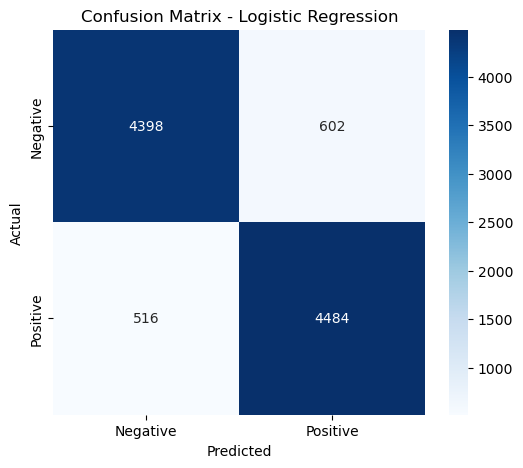

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


### 14. Test on Custom Example Sentences

Tests the trained model on 3 original sentences, cleaned with the same function and transformed with the same fitted vectorizer used during training.

In [16]:
example_sentences = [
    "This was the best experience ever",
    "This was a complete waste of time",
    "The movie was okay, not great but not terrible either"
]

cleaned_examples = [clean_text(sentence) for sentence in example_sentences]
example_vectors = vectorizer.transform(cleaned_examples)

example_predictions = lr_model.predict(example_vectors)
example_probabilities = lr_model.predict_proba(example_vectors)

for sentence, prediction, probability in zip(example_sentences, example_predictions, example_probabilities):
    label = "Positive" if prediction == 1 else "Negative"
    confidence = probability[prediction]
    print(f"'{sentence}' -> {label} (confidence: {confidence:.4f})")


'This was the best experience ever' -> Positive (confidence: 0.9813)
'This was a complete waste of time' -> Negative (confidence: 0.9974)
'The movie was okay, not great but not terrible either' -> Negative (confidence: 0.8884)


### 15. Final Summary

**Approach:** Raw IMDB review text was lowercased, HTML tags removed, and punctuation/numbers stripped, then converted into 5000 TF-IDF features with English stop words removed. Data was split 80/20 for training and testing.

**Model choice:** Logistic Regression was chosen over Multinomial Naive Bayes after direct comparison -- it achieved higher accuracy (~0.8885 vs ~0.8531) and F1-score (~0.8895 vs ~0.8540) on this dataset.

**Results in plain terms:** the model correctly classifies sentiment for roughly 89% of held-out reviews it has never seen. Because this dataset is perfectly balanced (25,000/25,000), this accuracy figure is a genuine, non-inflated measure of performance, unlike Week 2's classification task where a 96/4 class imbalance made accuracy alone misleading.

**Limitation:** the model struggles with mixed or neutral sentiment. The third custom sentence above, "The movie was okay, not great but not terrible either," was confidently classified as Negative, despite being genuinely ambivalent. The model was trained only on clearly positive or clearly negative reviews, with no neutral category, so it has no mechanism for expressing uncertainty, and appears to latch onto strong individual words like "terrible" even when surrounding context softens their meaning. Sarcasm is a closely related limitation: a sarcastic sentence with positive-sounding words but a negative intended meaning would likely be misread the same way, since the model has no way to detect tone.

**Next steps:** a model that captures word order and context, such as an LSTM or a transformer-based model (e.g. BERT), would likely handle mixed sentiment and sarcasm better than a bag-of-words TF-IDF approach, at the cost of requiring more data and compute to train effectively.